# Estudo dos Hiperparâmetros
Explora o espaço de hiperparâmetros com curvas de aprendizado para definir ranges pro Optuna.

In [1]:
#Bibliotecas Utilizadas
import os
from pathlib import Path
from dotenv import load_dotenv
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import itertools
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np


In [5]:
import sys
print(sys.executable)

c:\Users\Workstation\anaconda3\python.exe


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device selecionado:", device)
print("GPU:", torch.cuda.get_device_name(0))

Device selecionado: cpu


AssertionError: Torch not compiled with CUDA enabled

In [8]:
load_dotenv()
DATA_PATH = os.getenv("DADOS_PROJETO")
dados = torch.load(DATA_PATH)

In [9]:
X_train_num      = dados['X_train_num'].float()
X_train_emb_base = dados['X_train_emb_base'].long()
X_train_emb_add  = dados['X_train_emb_add'].long()
y_train          = dados['y_train'].float()

X_test_num       = dados['X_test_num'].float()
X_test_emb_base  = dados['X_test_emb_base'].long()
X_test_emb_add   = dados['X_test_emb_add'].long()
y_test           = dados['y_test'].float()

NUM_FEATURES_CONTINUAS = X_train_num.shape[1]
VOCAB_BASE_SIZE        = int(X_train_emb_base.max().item() + 1)
VOCAB_ADD_SIZE         = int(X_train_emb_add.max().item() + 1)

print(f'Features contínuas : {NUM_FEATURES_CONTINUAS}')
print(f'Vocab base         : {VOCAB_BASE_SIZE}')
print(f'Vocab consumível   : {VOCAB_ADD_SIZE}')
print(f'Treino             : {X_train_num.shape[0]} amostras')
print(f'Teste              : {X_test_num.shape[0]} amostras')

Features contínuas : 74
Vocab base         : 72
Vocab consumível   : 73
Treino             : 609 amostras
Teste              : 153 amostras


In [10]:
class RedeSoldagem(nn.Module):
    def __init__(self, num_features_continuas, vocab_base_size, vocab_add_size,
                 emb_dim=4, hidden_size=64, num_layers=2, dropout_rate=0.2,activation=nn.ReLU()):
        super().__init__()
        self.emb_base = nn.Embedding(vocab_base_size, emb_dim)
        self.emb_add  = nn.Embedding(vocab_add_size,  emb_dim)
        entrada = num_features_continuas + emb_dim * 2
        camadas, atual = [], entrada
        for _ in range(num_layers):
            camadas += [nn.Linear(atual, hidden_size), activation,
                        nn.BatchNorm1d(hidden_size), nn.Dropout(dropout_rate)]
            atual = hidden_size
        self.ocultas = nn.Sequential(*camadas)
        self.saida   = nn.Linear(hidden_size, 3)

    def forward(self, x_num, x_base, x_add):
        x = torch.cat([x_num, self.emb_base(x_base), self.emb_add(x_add)], dim=1)
        return self.saida(self.ocultas(x))

## Função de treino com registro de curvas


In [11]:
def treinar_com_historico(params, epochs=100, batch_size=32):
    model = RedeSoldagem(
        num_features_continuas=NUM_FEATURES_CONTINUAS,
        vocab_base_size=VOCAB_BASE_SIZE,
        vocab_add_size=VOCAB_ADD_SIZE,
        emb_dim=params['emb_dim'],
        hidden_size=params['hidden_size'],
        num_layers=params['num_layers'],
        dropout_rate=params['dropout_rate'],
        activation=params.get('activation', nn.ReLU()),
    ).to(device)

    dataset = TensorDataset(X_train_num, X_train_emb_base, X_train_emb_add, y_train)
    pin = True if device.type == 'cuda' else False
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True, pin_memory=pin)
    optimizer = params['optimizer'](model.parameters(), lr=params['learning_rate'])
    criterion = params['criterion']
    historico_train = []
    historico_val = []

    for epoca in range(epochs):
        model.train()
        losses_batch = []
        for x_num, x_base, x_add, y_batch in loader:
            # mover batch para device (non_blocking se pin_memory True)
            nb = True if pin else False
            x_num = x_num.to(device, non_blocking=nb)
            x_base = x_base.to(device, non_blocking=nb)
            x_add = x_add.to(device, non_blocking=nb)
            y_batch = y_batch.to(device, non_blocking=nb)

            pred = model(x_num, x_base, x_add)
            loss = criterion(pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses_batch.append(loss.item())
        historico_train.append(np.mean(losses_batch))

        model.eval()
        with torch.no_grad():
            pred_val = model(X_test_num.to(device), X_test_emb_base.to(device), X_test_emb_add.to(device))
            val_loss = criterion(pred_val, y_test.to(device)).item()
        historico_val.append(val_loss)

    return val_loss, historico_train, historico_val

### Grid de exploração
Estratégia: explorar amplamente primeiro para entender quais regiões do espaço são promissoras

In [12]:
param_grid = {
    'learning_rate': [1e-4, 1e-3, 5e-3], 
    'hidden_size':   [64, 128, 256],
    'num_layers':    [1, 2, 3],
    'dropout_rate':  [0.0, 0.05, 0.1],
    'emb_dim':       [4, 8, 12],
    'activation':    [nn.ReLU(), nn.GELU(), nn.LeakyReLU(0.01)],
    'criterion':     [nn.MSELoss(), nn.L1Loss()],
    'optimizer':     [optim.Adam, optim.SGD, optim.RMSprop, optim.AdamW]
}

all_combos = list(itertools.product(*param_grid.values()))
keys = list(param_grid.keys())
print(f'Total de combinações possíveis: {len(all_combos)}')

SEED = 32
random.seed(SEED)
sample = random.sample(all_combos, k=30)
print(f'Amostras selecionadas para rodar: {len(sample)}')

Total de combinações possíveis: 5832
Amostras selecionadas para rodar: 30


In [13]:
# ── Executar o manual search ──────────────────────────────────────────────────

EPOCHS     = 100  
BATCH_SIZE = 32

resultados = []

for i, combo in enumerate(sample):
    params = dict(zip(keys, combo))
    label  = f"hs={params['hidden_size']} nl={params['num_layers']} lr={params['learning_rate']:.0e} dr={params['dropout_rate']} emb={params['emb_dim']}"

    val_loss, hist_train, hist_val = treinar_com_historico(params, epochs=EPOCHS, batch_size=BATCH_SIZE)

    resultados.append({
        **params,
        'val_loss':   val_loss,
        'label':      label,
        'hist_train': hist_train,
        'hist_val':   hist_val,
    })
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if (i + 1) % 5 == 0:
        print(f'[{i+1}/{len(sample)}] melhor até agora: {min(r["val_loss"] for r in resultados):.4f}')

df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('hist_train', 'hist_val')} for r in resultados])
df = df.sort_values('val_loss').reset_index(drop=True)
print('\nTop 10:')
print(df.head(10).to_string(index=False))

KeyboardInterrupt: 


### Visualização 1 — Curvas de aprendizado (top 10 vs 5 piores )
Mostra onde cada combinação para de aprender e se há overfitting.

In [ ]:
# Ordenar resultados por val_loss final
resultados_sorted = sorted(resultados, key=lambda r: r['val_loss'])
top10   = resultados_sorted[:10]
piores5 = resultados_sorted[-5:]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Curvas de aprendizado — Manual Search', fontsize=14, fontweight='bold', y=1.01)

CORES_TOP   = plt.cm.viridis(np.linspace(0.2, 0.9, len(top10)))
CORES_RUINS = plt.cm.Reds(np.linspace(0.4, 0.9, len(piores5)))
epocas      = range(1, EPOCHS + 1)

# ── Painel superior: top 10 ──
ax = axes[0]
for i, r in enumerate(top10):
    ax.plot(epocas, r['hist_val'], color=CORES_TOP[i], linewidth=1.6,
            label=f"#{i+1} loss={r['val_loss']:.2f} | {r['label']}")
ax.set_title('Top 10 combinações — val loss por época', fontsize=12)
ax.set_xlabel('Época')
ax.set_ylabel('Val Loss (MSE)')
ax.legend(fontsize=7, loc='upper right', ncol=1)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')  # escala log para ver a diferença entre os bons

# ── Painel inferior: melhores vs piores (val E train) ──
ax2 = axes[1]
melhor = resultados_sorted[0]
pior   = resultados_sorted[-1]

ax2.plot(epocas, melhor['hist_train'], 'b-',  linewidth=2.0, label=f'Melhor — train (loss={melhor["val_loss"]:.2f})')
ax2.plot(epocas, melhor['hist_val'],   'b--', linewidth=2.0, label=f'Melhor — test')
ax2.plot(epocas, pior['hist_train'],   'r-',  linewidth=1.5, label=f'Pior — train (loss={pior["val_loss"]:.2f})', alpha=0.7)
ax2.plot(epocas, pior['hist_val'],     'r--', linewidth=1.5, label=f'Pior — test', alpha=0.7)

# Marcar onde o melhor satura (derivada ~0)
hist_val_melhor = np.array(melhor['hist_val'])
diffs = np.abs(np.diff(hist_val_melhor))
saturacao = np.argmax(diffs < diffs.max() * 0.02)  # onde variação cai para <2% do máximo
if saturacao > 5:
    ax2.axvline(x=saturacao, color='blue', linestyle=':', alpha=0.6)
    ax2.text(saturacao + 1, hist_val_melhor[saturacao], f'satura ~época {saturacao}',
             fontsize=9, color='blue', alpha=0.8)

ax2.set_title('Melhor vs pior: train e test — detectando overfitting e saturação', fontsize=12)
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss (MSE)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

Learning Curves 
- val = indica que o treino é mais dificil que a validação

## Visualização 2 — Impacto de cada hiperparâmetro
Boxplot mostrando a distribuição de `val_loss` para cada valor de cada parâmetro.
Parâmetros com boxes bem separados = alta influência.

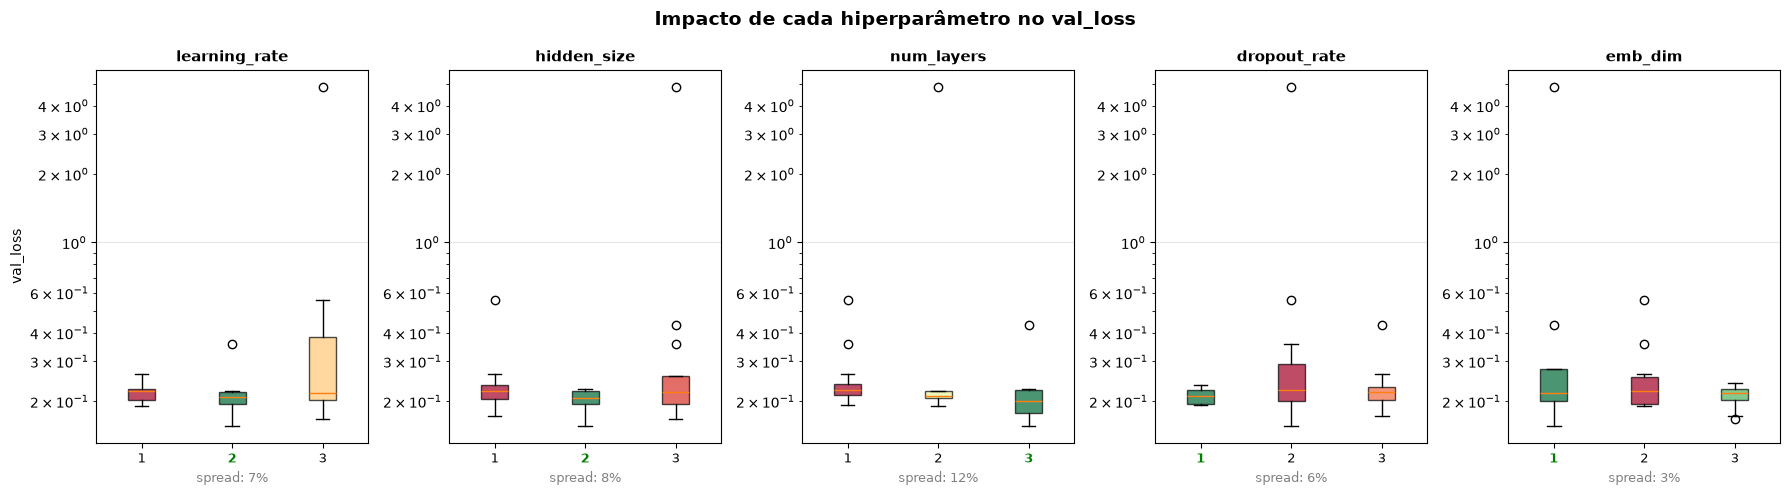


► Parâmetros com maior spread = mais importantes para o Optuna


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Impacto de cada hiperparâmetro no val_loss', fontsize=14, fontweight='bold')

for ax, col in zip(axes, keys):
    grupos  = df.groupby(col)['val_loss'].apply(list)
    valores = [grupos[k] for k in sorted(grupos.index)]
    labels  = [str(k) for k in sorted(grupos.index)]

    bp = ax.boxplot(valores, label=label, patch_artist=True, notch=False)

    # Colorir caixas do melhor para o pior pela mediana
    medianas = [np.median(v) for v in valores]
    norma    = plt.Normalize(min(medianas), max(medianas))
    for patch, med in zip(bp['boxes'], medianas):
        patch.set_facecolor(plt.cm.RdYlGn_r(norma(med)))
        patch.set_alpha(0.7)

    # Marcar o melhor valor de cada parâmetro
    melhor_idx = np.argmin(medianas)
    ax.get_xticklabels()[melhor_idx].set_color('green')
    ax.get_xticklabels()[melhor_idx].set_fontweight('bold')

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('val_loss' if ax == axes[0] else '')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', labelsize=9)

    # Anotação: spread relativo (quanto varia entre valores)
    spread = (max(medianas) - min(medianas)) / min(medianas) * 100
    ax.set_xlabel(f'spread: {spread:.0f}%', fontsize=9, color='gray')

plt.tight_layout()

plt.show()

print('\n► Parâmetros com maior spread = mais importantes para o Optuna')

## Visualização 3 — Curvas de saturação agrupadas por parâmetro
Para cada parâmetro, plota as curvas médias de aprendizado separadas por valor.
Mostra se um valor de parâmetro aprende mais rápido, satura antes, ou converge melhor.

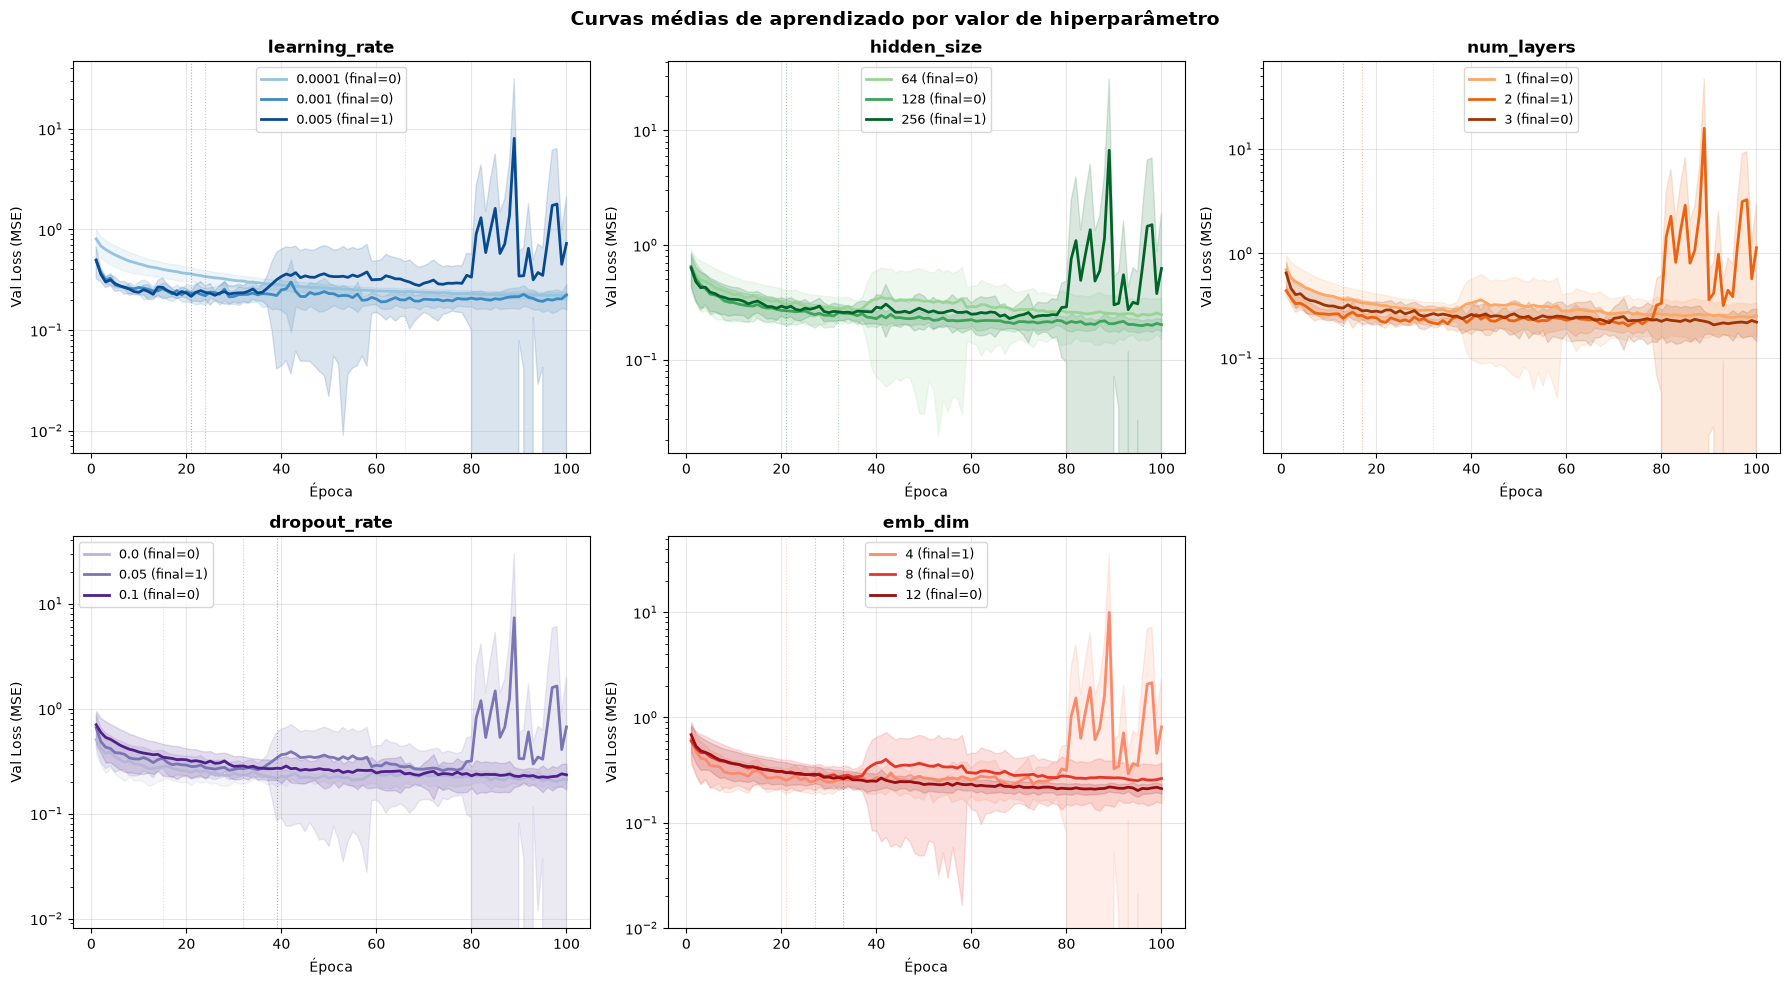

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Curvas médias de aprendizado por valor de hiperparâmetro', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

# Paleta consistente por valor de parâmetro
PALETAS = [plt.cm.Blues, plt.cm.Greens, plt.cm.Oranges, plt.cm.Purples, plt.cm.Reds]

for idx, (col, paleta) in enumerate(zip(keys, PALETAS)):
    ax     = axes_flat[idx]
    grupos = {}
    for r in resultados:
        v = r[col]
        if v not in grupos:
            grupos[v] = []
        grupos[v].append(r['hist_val'])

    valores_sorted = sorted(grupos.keys())
    cores = paleta(np.linspace(0.4, 0.9, len(valores_sorted)))

    for val, cor in zip(valores_sorted, cores):
        curvas     = np.array(grupos[val])            # shape: (n_runs, epochs)
        media      = curvas.mean(axis=0)
        desvio     = curvas.std(axis=0)
        loss_final = media[-1]

        ax.plot(range(1, EPOCHS + 1), media, color=cor, linewidth=2,
                label=f'{val} (final={loss_final:.0f})')
        ax.fill_between(range(1, EPOCHS + 1),
                         media - desvio, media + desvio,
                         color=cor, alpha=0.15)

        # Marcar época de saturação (quando a curva não melhora mais que 1%)
        for ep in range(10, EPOCHS - 1):
            if abs(media[ep] - media[ep - 5]) / (media[ep - 5] + 1e-8) < 0.01:
                ax.axvline(x=ep, color=cor, linestyle=':', alpha=0.4, linewidth=0.8)
                break

    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('Val Loss (MSE)')
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Esconder o último subplot vazio
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()


## Visualização 4 — Heatmap de interações entre parâmetros
Mostra pares de parâmetros e a val_loss média para cada combinação de valores.
Útil para ver se há interações fortes (ex: `hidden_size` alto só ajuda com `lr` adequado).

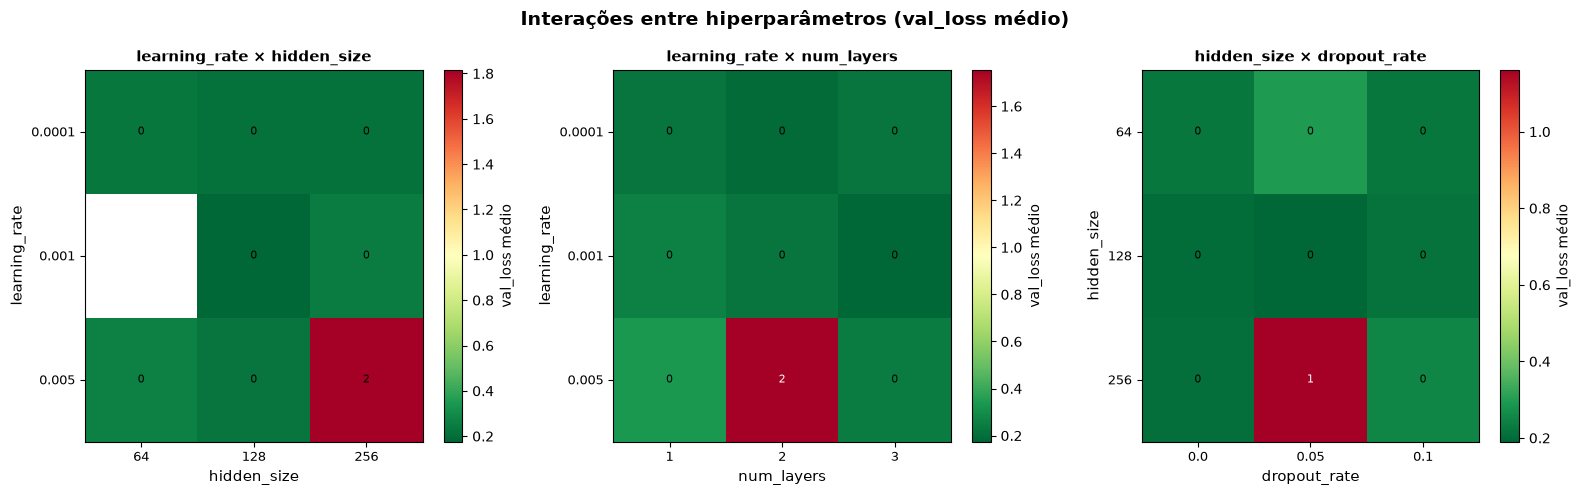

In [ ]:
# Os 3 pares mais relevantes (entre os parâmetros de maior impacto)
pares = [
    ('learning_rate', 'hidden_size'),
    ('learning_rate', 'num_layers'),
    ('hidden_size',   'dropout_rate'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Interações entre hiperparâmetros (val_loss médio)', fontsize=14, fontweight='bold')

for ax, (p1, p2) in zip(axes, pares):
    pivot = df.pivot_table(index=p1, columns=p2, values='val_loss', aggfunc='mean')

    im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')
    plt.colorbar(im, ax=ax, label='val_loss médio')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels([str(c) for c in pivot.columns], fontsize=9)
    ax.set_yticklabels([str(i) for i in pivot.index], fontsize=9)
    ax.set_xlabel(p2, fontsize=11)
    ax.set_ylabel(p1, fontsize=11)
    ax.set_title(f'{p1} × {p2}', fontsize=11, fontweight='bold')

    # Anotar cada célula com o valor
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=8,
                        color='white' if val > pivot.values.mean() else 'black')

plt.tight_layout()
plt.show()


## Resumo e ranges recomendados para o Optuna
Com base nos gráficos acima, identifica automaticamente os melhores ranges.

In [ ]:
# Pegar o top 20% dos resultados e ver os ranges que apareceram
n_top = max(3, len(df) // 5)  # top 20%
df_top = df.head(n_top)

print('=' * 60)
print(f'ANÁLISE DOS TOP {n_top} RESULTADOS (20% melhores)')
print('=' * 60)
print(f'\nVal loss:  min={df_top.val_loss.min():.1f}  max={df_top.val_loss.max():.1f}')

print('\nRanges que apareceram nos melhores resultados:')
for col in keys:
    vals = df_top[col].unique()
    print(f'  {col:15s}: {sorted(vals)}')

print('\n' + '=' * 60)
print('RANGES SUGERIDOS PARA O OPTUNA (fase 2):')
print('=' * 60)

for col in keys:
    vals = sorted(df_top[col].unique())
    if len(vals) >= 2:
        lo, hi = vals[0], vals[-1]
        # Expandir levemente os limites para o Optuna explorar além dos pontos testados
        if col == 'learning_rate':
            print(f'  trial.suggest_float("{col}", {lo*0.5:.1e}, {hi*2:.1e}, log=True)')
        elif col in ('hidden_size', 'num_layers', 'emb_dim'):
            print(f'  trial.suggest_int("{col}", {int(lo)}, {int(hi)})')
        else:
            print(f'  trial.suggest_float("{col}", {lo:.2f}, {hi:.2f})')
    else:
        print(f'  # {col} = {vals[0]} (fixar — pouca variação no top)')

ANÁLISE DOS TOP 6 RESULTADOS (20% melhores)

Val loss:  min=0.2  max=0.2

Ranges que apareceram nos melhores resultados:
  learning_rate  : [np.float64(0.0001), np.float64(0.001), np.float64(0.005)]
  hidden_size    : [np.int64(64), np.int64(128), np.int64(256)]
  num_layers     : [np.int64(1), np.int64(2), np.int64(3)]
  dropout_rate   : [np.float64(0.0), np.float64(0.05), np.float64(0.1)]
  emb_dim        : [np.int64(4), np.int64(8), np.int64(12)]

RANGES SUGERIDOS PARA O OPTUNA (fase 2):
  trial.suggest_float("learning_rate", 5.0e-05, 1.0e-02, log=True)
  trial.suggest_int("hidden_size", 64, 256)
  trial.suggest_int("num_layers", 1, 3)
  trial.suggest_float("dropout_rate", 0.00, 0.10)
  trial.suggest_int("emb_dim", 4, 12)


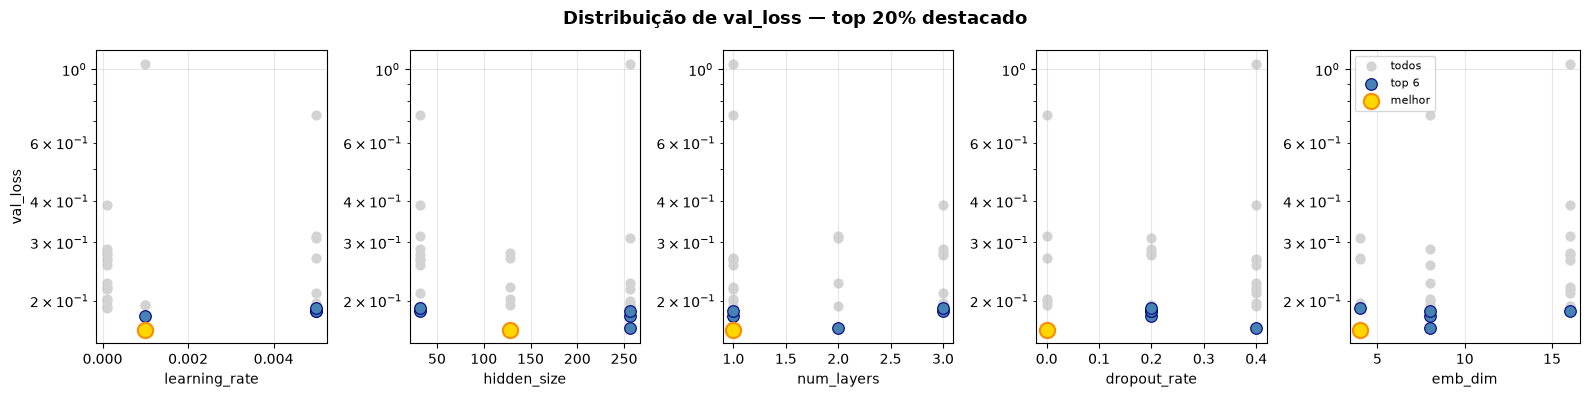

In [ ]:
# ── Gráfico final: resumo visual dos ranges ──────────────────────────────────
fig, axes = plt.subplots(1, len(keys), figsize=(16, 4))
fig.suptitle('Distribuição de val_loss — top 20% destacado', fontsize=13, fontweight='bold')

for ax, col in zip(axes, keys):
    # Todos os resultados
    ax.scatter(df[col], df['val_loss'], color='lightgray', s=40, zorder=1, label='todos')
    # Top 20% em destaque
    ax.scatter(df_top[col], df_top['val_loss'], color='steelblue', s=70, zorder=2,
               edgecolors='navy', linewidths=0.8, label=f'top {n_top}')
    # Melhor resultado
    melhor_row = df.iloc[0]
    ax.scatter(melhor_row[col], melhor_row['val_loss'], color='gold', s=120, zorder=3,
               edgecolors='darkorange', linewidths=1.5, label='melhor')

    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('val_loss' if ax == axes[0] else '')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    if ax == axes[-1]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
import optuna
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float("learning_rate", 5.0e-04, 1.0e-02, log=True),
        'hidden_size':   trial.suggest_int("hidden_size", 32, 128),
        'num_layers':    trial.suggest_int("num_layers", 2, 3),
        'dropout_rate':  trial.suggest_float("dropout_rate", 0.00, 0.1),
        'emb_dim':       trial.suggest_int("emb_dim", 1,4)
    }
    
    model = RedeSoldagem(
        num_features_continuas=NUM_FEATURES_CONTINUAS,
        vocab_base_size=VOCAB_BASE_SIZE,
        vocab_add_size=VOCAB_ADD_SIZE,
        emb_dim=params['emb_dim'],
        hidden_size=params['hidden_size'],
        num_layers=params['num_layers'],
        dropout_rate=params['dropout_rate']
    )

    dataset   = TensorDataset(X_train_num, X_train_emb_base, X_train_emb_add, y_train)
    loader    = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])

    # Considerando a saturação média em torno de ~40 épocas, podemos usar um limite seguro aqui:
    epochs = 40
    
    for epoca in range(epochs):
        model.train()
        for x_num, x_base, x_add, y_batch in loader:
            pred = model(x_num, x_base, x_add)
            loss = criterion(pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_val = model(X_test_num, X_test_emb_base, X_test_emb_add)
        val_loss = criterion(pred_val, y_test).item()

    return val_loss

# 4. Executando a Otimização
if __name__ == "__main__":
    # Silenciar o log verboso do Optuna para não poluir o terminal


    study = optuna.create_study(direction="minimize")
    
    print("Iniciando otimização com Optuna (Fase 2)... Aguarde.")
    # k=20 ou 30 trials costuma ser suficiente para refinar bem a busca
    study.optimize(objective, n_trials=25)

    print("\n" + "=" * 50)
    print("Otimização Concluída!")
    print("=" * 50)
    print(f"Melhor Val Loss (MSE): {study.best_value:.2f}")
    print("\nMelhores Hiperparâmetros Encontrados:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

Iniciando otimização com Optuna (Fase 2)... Aguarde.

Otimização Concluída!
Melhor Val Loss (MSE): 0.16

Melhores Hiperparâmetros Encontrados:
  learning_rate: 0.0029773854195867862
  hidden_size: 90
  num_layers: 3
  dropout_rate: 0.008224015109369676
  emb_dim: 4


In [ ]:
optuna.importance.get_param_importances()

TypeError: get_param_importances() missing 1 required positional argument: 'study'